### normalising the data is very important for some algorithems to performe better for that different techniques are used
. log tranformer : used for right skewed data mostly  , cant be used for neg values or left skewd data

. sqaure tranformer : used for left skewed data mostly

. reciprocal transformer : used for Strong right-skewed data , Cannot handle zeros. Negative values flip sign, which may distort meaning.

. square root transformer : Mild right-skewed data , Cannot handle negative values. Limited effect on heavy skew.

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score
import numpy as np

data = pd.read_csv(r"C:\Users\pc\Downloads\Titanic-Dataset.csv") 
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [96]:
data["Age"] = pd.to_numeric(data["Age"],errors= "coerce")
data["Age"] = data["Age"].fillna(data["Age"].median())


<Axes: xlabel='Age', ylabel='Count'>

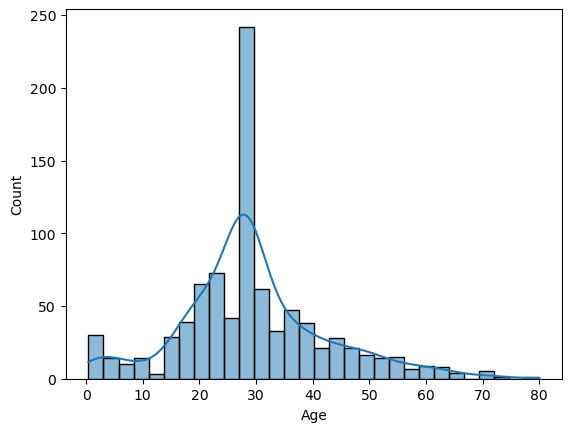

In [97]:
sns.histplot(data, x = "Age", kde = True,bins = 30)

<Axes: xlabel='Fare', ylabel='Count'>

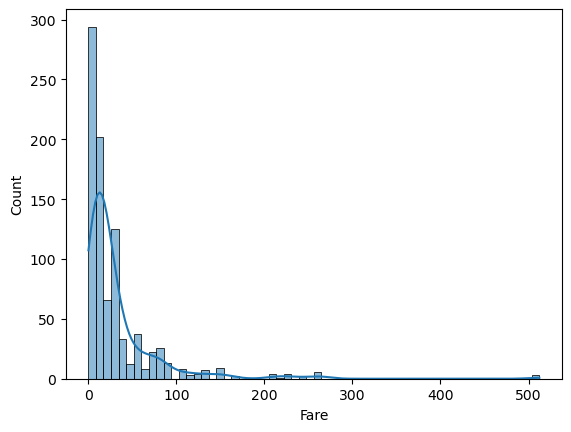

In [98]:
sns.histplot(data["Fare"], kde = True)

In [99]:
# prediction withut normilisng data

X = data[["Age","Fare"]]
y = data["Survived"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,shuffle= True,random_state= 42)
model = LogisticRegression()

model.fit(X_train,y_train)


LogisticRegression()

In [100]:
prediction = model.predict(X_test)

In [101]:
accuracy_score(y_test,prediction)

0.6480446927374302

In [ ]:
tf = FunctionTransformer(func = np.log1p)
ndata = tf.fit_transform(data[['Age','Fare']])


<Axes: xlabel='Age', ylabel='Count'>

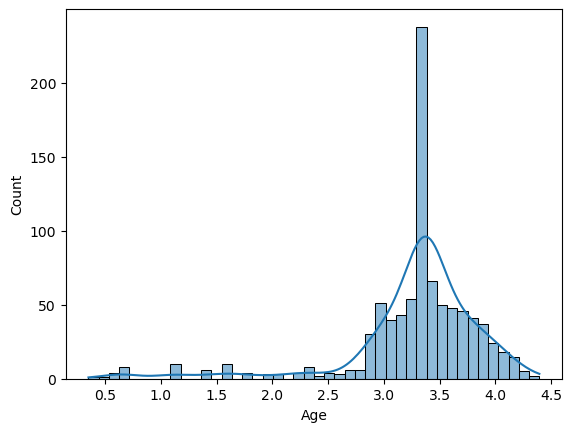

In [103]:
sns.histplot( ndata['Age'],kde = True)

<Axes: xlabel='Fare', ylabel='Count'>

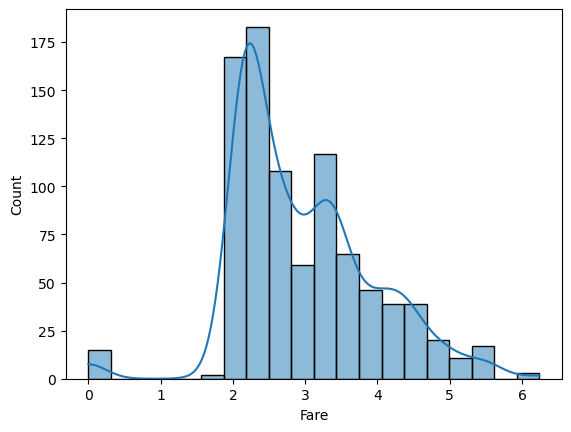

In [104]:
sns.histplot(ndata['Fare'],kde = True,bins = 20)

In [116]:
nmodel = LogisticRegression()
X = ndata[['Age','Fare']]
y = data['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model.fit(X_train,y_train)
npred = model.predict(X_test)


In [117]:
accuracy_score(npred,y_test)


0.664804469273743

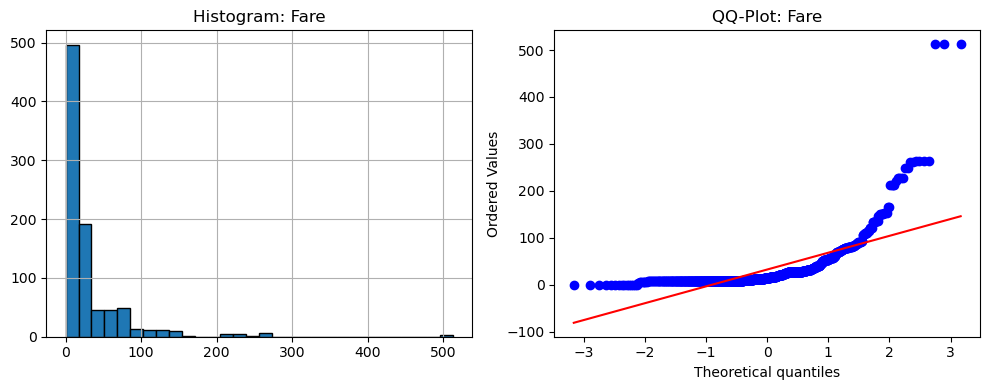

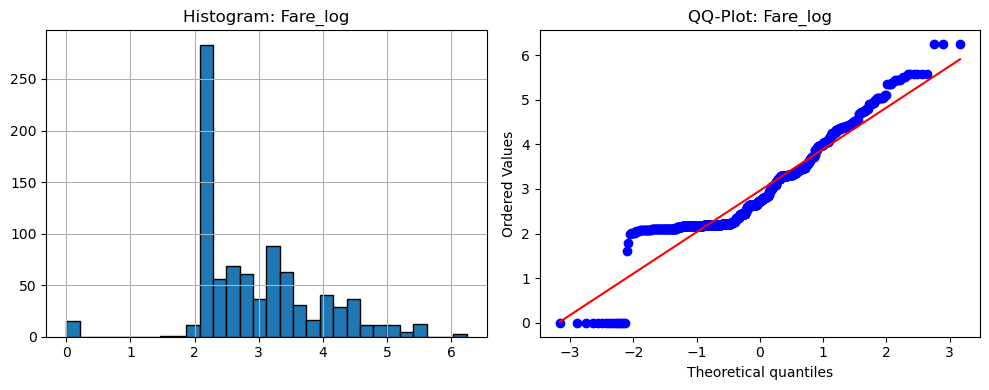

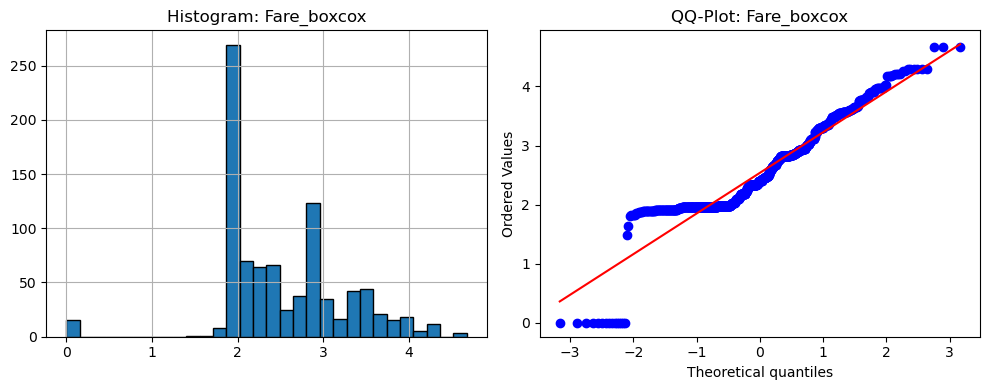

Original Skew: 4.787316519674893
Log Skew:      0.3949280095189306
Box-Cox Skew:  -0.04032915137339973


In [120]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load Data
data = pd.read_csv(r"C:\Users\pc\Downloads\Titanic-Dataset.csv")

# 2. Helper function to plot Histogram & QQ-Plot side by side
def plot_data(df, feature):
    plt.figure(figsize=(10, 4))
    
    # Histogram / KDE
    plt.subplot(1, 2, 1)
    df[feature].hist(bins=30, edgecolor="black")
    plt.title(f"Histogram: {feature}")
    
    # Probability / QQ Plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[feature], dist="norm", plot=plt)
    plt.title(f"QQ-Plot: {feature}")
    
    plt.tight_layout()
    plt.show()

# 3. Handle 'Fare' Normalization Techniques (Zero-safe)
fare_df = data[['Fare']].dropna().copy()

fare_df['Fare_log'] = np.log1p(fare_df['Fare'])
fare_df['Fare_sqrt'] = np.sqrt(fare_df['Fare'])
fare_df['Fare_boxcox'], _ = stats.boxcox(fare_df['Fare'] + 1) # Requires > 0

# Check original vs transformed distribution
plot_data(fare_df, 'Fare')
plot_data(fare_df, 'Fare_log')
plot_data(fare_df, 'Fare_boxcox')

# 4. Check Skewness reduction directly
print("Original Skew:", fare_df['Fare'].skew())
print("Log Skew:     ", fare_df['Fare_log'].skew())
print("Box-Cox Skew: ", fare_df['Fare_boxcox'].skew())

In [ ]:
tf1 FunctionTransformer(np.sqrt)
tf1 FunctionTransformer(np.log1p)
tf1 FunctionTransformer(np.)
